# 7 - Classical Neo-Riemannian Transformations

## Import + Functions

In [73]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [75]:
%reload_ext autoreload
import pandas as pd
from fractions import Fraction
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import music21 as m21
import re

import sys
sys.path.append('/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/')

from Importables import General as g
from Importables import intervalanalysis_utils as ia
from Importables import tonnetz_utils as t
from Importables import pitchanalysis_utils as pa

In [ ]:
import ms3
def get_key(row_harm, keys):
    try:
        if keys == 'local':
            tonic = row_harm['globalkey']
            mode = 'minor' if row_harm['globalkey_is_minor'] == 1 else 'major'
            k = m21.key.Key(tonic, mode)
            
            local_key_raw = row_harm['localkey']
            local_mode = 'minor' if row_harm['localkey_is_minor'] == 1 else 'major'
        
            local_key_chord = m21.roman.RomanNumeral(local_key_raw, k)
            local_tonic = local_key_chord.root()
        
            key = m21.key.Key(local_tonic, local_mode)

        elif keys == 'global':
            global_tonic = row_harm['globalkey'] 
            global_mode = 'minor' if row_harm['globalkey_is_minor'] == 1 else 'major'
            key = m21.key.Key(global_tonic, global_mode)

        else:
            raise ValueError(f"Invalid key_type '{key_type}'. Must be 'local' or 'global'.")
                    
        return str(key)
    except Exception as e:
        print(f'{e}')
        return np.nan
        

In [164]:
def load_notes(metadata, keys=False):

    dfs = []
    for _, row in metadata.iterrows():
        corpus = row['corpus']
        piece = row['piece']
        
        notes_path = f"/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/dcml_corpora/{corpus}/notes/{piece}.notes.tsv"
        
        try: 
            df_notes = pd.read_csv(notes_path, sep='\t')
            df_notes['mc'] = df_notes['mc'].astype(int)

            df_notes['pc'] = df_notes['midi'] % 24
            df_notes['pc'] = df_notes['pc'].apply(int)

            df_notes['note'] = df_notes['tpc'].apply(ms3.tpc2name)
            df_notes['note'] = df_notes['note'].apply(g.fix_flats)
        
            df_notes['mc_onset'] = df_notes['mc_onset'].astype(str).apply(lambda x: float(Fraction(x)))
            df_notes['duration'] = df_notes['duration'].astype(str).apply(lambda x: float(Fraction(x)))
            df_notes['time'] = df_notes['mc'] + df_notes['mc_onset']

            df_notes['corpus'] = corpus
            df_notes['piece'] = piece
            df_notes['recording_year'] = row['composed_start']

            df_notes = df_notes.sort_values(by='time')

            if isinstance(keys, str):
                harm_path = f'/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/dcml_corpora/{corpus}/harmonies/{piece}.harmonies.tsv'
                df_harm = pd.read_csv(harm_path, sep='\t')

                df_harm['key'] = df_harm.apply(lambda row: get_key(row, keys), axis=1)
                    
                df_harm['mc_onset'] = df_harm['mc_onset'].astype(str).apply(lambda x: float(Fraction(x)))
                df_harm['duration_qb'] = df_harm['duration_qb'].astype(str).apply(lambda x: float(Fraction(x)))
                df_harm['time'] = df_harm['mc'] + df_harm['mc_onset']

                df_harm = df_harm.sort_values(by='time')
                
                df_notes = df_notes.merge(df_harm[['time','key']], on='time', how='left')
                df_notes['key'] = df_notes['key'].ffill()
                    
            dfs.append(df_notes)

        except Exception as e:
            #print(f'{e}')
            continue
    
    dfs = pd.concat(dfs, ignore_index=True)
    
    return dfs

In [77]:
def update_chord_labels(df):
    """
    updates chord according to local key

    Args:
        df: pd.Dataframe with local key, global key and chord

    Return:
        df: pd.Dataframe with updated chord
        exceptions: pd.Dataframe with chords/roman numeral that threw exceptiom
    """
    exceptions = []
    labels_updated = []
    chord_updated = []
    
    for _, row in df.iterrows():
        tonic = row['globalkey']
        mode = 'minor' if row['globalkey_is_minor'] == 1 else 'major'
        k = m21.key.Key(tonic, mode)
        
        chord = row['chord']
        
        local_key_raw = row['localkey']
        local_mode = 'minor' if row['localkey_is_minor'] == 1 else 'major'
    
        local_key_chord = m21.roman.RomanNumeral(local_key_raw, k)
        local_tonic = local_key_chord.root()
    
        key = m21.key.Key(local_tonic, local_mode)
    
        rn = np.nan
        
        try:
            rn = m21.roman.RomanNumeral(chord, key)
            chord_updated.append(chord)
        except:
            try:
                numeral = row['numeral']
                rn = m21.roman.RomanNumeral(numeral, key)
                chord_updated.append(numeral)
                
            except:
                rn = np.nan
                chord_updated.append(numeral)
                exceptions.append({
                    "chord": row['chord'],
                    "numeral": row['numeral']
                })
            
    
        labels_updated.append(rn)
        
    df = df.copy()    
    df['label_updated'] = labels_updated
    df['chord_updated'] = chord_updated
    exceptions = pd.DataFrame(exceptions)

    return df, exceptions

In [79]:
def transformation(labels):
    """
    Returns dataframe with single transformation information

    Args:
        labels: pd.DataFrame, generated from g.load_labels

    Return:
        df: pd.DataFrame with columns ['chord_1', 'chord_2', 'transformation', 'artist', 'fname', 'recording_year']
        exceptions: list of chord labels that threw exceptions (possibly not readable by music21)
    """
    
    rows_list = []
    exceptions = []
    
    for piece in labels['piece'].unique():
        subset = labels[labels['piece'] == piece]
        
        last_label = subset.iloc[0]['label_updated']
        last_label_name = subset.iloc[0]['chord_updated']
        for index, row in subset.iterrows():
                
            current_label = row['label_updated']
            current_label_name = row['chord_updated']
            # look for different label
            if (current_label_name != last_label_name):
                result = None
                l1 = l3 = l5 = c1 = c3 = c5 = None 
    
                try:
                    result = None
                    l1 = last_label.root()
                    l3 = last_label.third
                    l5 = last_label.fifth
                except:
                    transformation = 'N/A'
                    if current_label_name not in exceptions:
                        exceptions.append(last_label_name)
    
                try:
                    c1 = current_label.root()
                    c3 = current_label.third
                    c5 = current_label.fifth
                except:
                    transformation = 'N/A'
                    if current_label_name not in exceptions:
                        exceptions.append(current_label_name)
        
                if None in (l1, l3, l5, c1, c3, c5):
                    transformation = 'N/A'
                    
                elif current_label.isDiminishedTriad() or current_label.isAugmentedTriad():
                    transformation = 'N/A'
                    if current_label_name not in exceptions:
                        exceptions.append(current_label_name)
    
                elif last_label.isDiminishedTriad() or last_label.isAugmentedTriad():
                    transformation = 'N/A'
                    if last_label_name not in exceptions:
                        exceptions.append(last_label_name)
                    
                # Parallel Case   
                elif t.is_parallel(l1,l3,l5,c1,c3,c5):
                    transformation = 'P'
    
                # Relative Case 
                elif t.is_relative(l1,l3,l5,c1,c3,c5):
                    transformation = 'R'
                    
                # Leading-Tone Exchange Case 
                elif t.is_leading(l1,l3,l5,c1,c3,c5):
                    transformation = 'L'
    
            
                # Slide Case 
                elif t.is_slide(l1,l3,l5,c1,c3,c5):
                    transformation = 'S'
                    
                # Nebenverwandt Case
                elif t.is_nebenverwandt(l1,l3,l5,c1,c3,c5):
                    transformation = 'N'
    
                # Hexpole case
                elif t.is_hexpole(l1,l3,l5,c1,c3,c5):
                    transformation = 'H'
    
                else:
                    # Check two-step sequence
                    seq = find_two_step_sequence(last_label, current_label)
                    if seq is not None:
                        transformation = seq
                    else:
                        transformation = 'N/A'
    
                result = {'chord_1': last_label_name, 
                          'chord_2': current_label_name,
                          'transformation': transformation,
                          'piece': piece,
                          'year': row['year'],
                          'year_bin': row['year_bin']
                         }
                    
                rows_list.append(result)        
                last_label_name = current_label_name
                last_label = current_label
            
    df = pd.DataFrame(rows_list) 

    return df, exceptions
    

In [81]:
def find_two_step_sequence(chord1, chord2):
    """
    Returns transformation pair between two chords

    Args:
        chord1_name: label1 string
        chord2_name: label2 string

    Return:
        Returns string of double transformation, None otherwise
    """
    transformations = {'P': t.P, 'R': t.R, 'L': t.L}

    for t1_name, t1_func in transformations.items():
        mid_chord = t1_func(chord1)

        if mid_chord is None:
            continue
        for t2_name, t2_func in transformations.items():
            mid_chord_copy = m21.chord.Chord([p for p in mid_chord.pitches])
            final_chord = t2_func(mid_chord_copy)
            if final_chord is None:
                continue
            try:
                if (final_chord.root().name == chord2.root().name and
                    final_chord.third.name == chord2.third.name and
                    final_chord.fifth.name == chord2.fifth.name):
                    return t1_name + t2_name
            except AttributeError:
                continue  # skip chords with missing components

    return None

## Mozart

In [88]:
mozart_metadata = pd.read_csv("../dcml_corpora/mozart_piano_sonatas/metadata.tsv", sep='\t')

In [90]:
mozart = []
for _, row in mozart_metadata.iterrows():
    piece = row['piece']
    path = '../dcml_corpora/mozart_piano_sonatas/harmonies/' + piece +'.harmonies.tsv'
    
    try:
        piece_df = pd.read_csv(path, sep='\t')
        piece_df['piece'] = piece
        piece_df['year'] = row['composed_start']
        mozart.append(piece_df)
    except:
        continue

mozart = pd.concat(mozart, ignore_index=True)

In [92]:
mozart_bins = np.arange(1770, 1791, 10) 
mozart_bin_labels = [f"{start}-{start+10}" for start in mozart_bins[:-1]]
mozart['year'] = pd.to_numeric(mozart['year'], errors='coerce')
mozart['year_bin'] = pd.cut(mozart['year'], bins=mozart_bins, labels=mozart_bin_labels, right=False)

In [94]:
mozart_updated, mozart_exceptions = update_chord_labels(mozart)
mozart_transformations, mozart_transform_exceptions = transformation(mozart_updated)

In [95]:
mozart_exceptions

,chord,numeral
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
...,...,...
237,NaN,NaN
238,NaN,NaN
239,NaN,NaN
240,NaN,NaN


In [96]:
mozart_NA = mozart_transformations[mozart_transformations['transformation'] == 'N/A'].copy()
print(mozart_NA.shape[0])
mozart_NA.value_counts(subset=['chord_1', 'chord_2']).reset_index(name='count').head(15) 

5914


,chord_1,chord_2,count
0,ii6,V,348
1,I6,ii6,173
2,I,ii6,145
3,IV,V,127
4,viio6,I6,93
5,viio6,I,92
6,viio7/V,V,82
7,I,viio6,81
8,viio,I,78
9,ii,V,66


In [97]:
mozart_transformations_cut = mozart_transformations[mozart_transformations['transformation'] != 'N/A'].copy()

<function matplotlib.pyplot.show(close=None, block=None)>

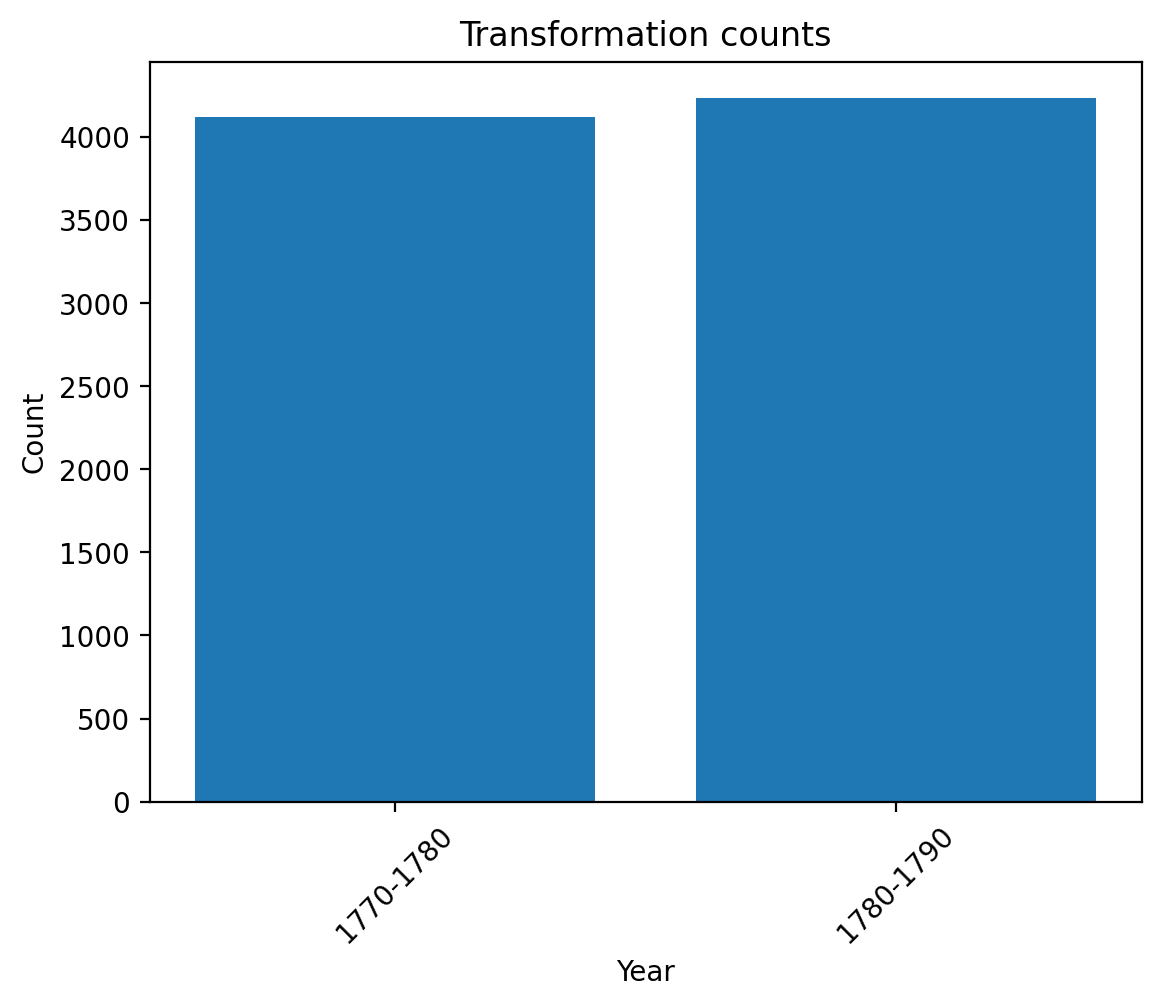

In [98]:
counts = mozart_transformations_cut.value_counts(subset=['year_bin']).reset_index(name='count')
counts = counts.sort_values('year_bin')
y = counts['count']
x = counts['year_bin'] 
plt.bar(x, y)
plt.title('Transformation counts')
plt.ylabel('Count')
plt.xlabel('Year')
plt.xticks(x,rotation=45)
plt.show

/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/Importables/tonnetz_utils.py:551: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(P_results['year_bin'], rotation=45)


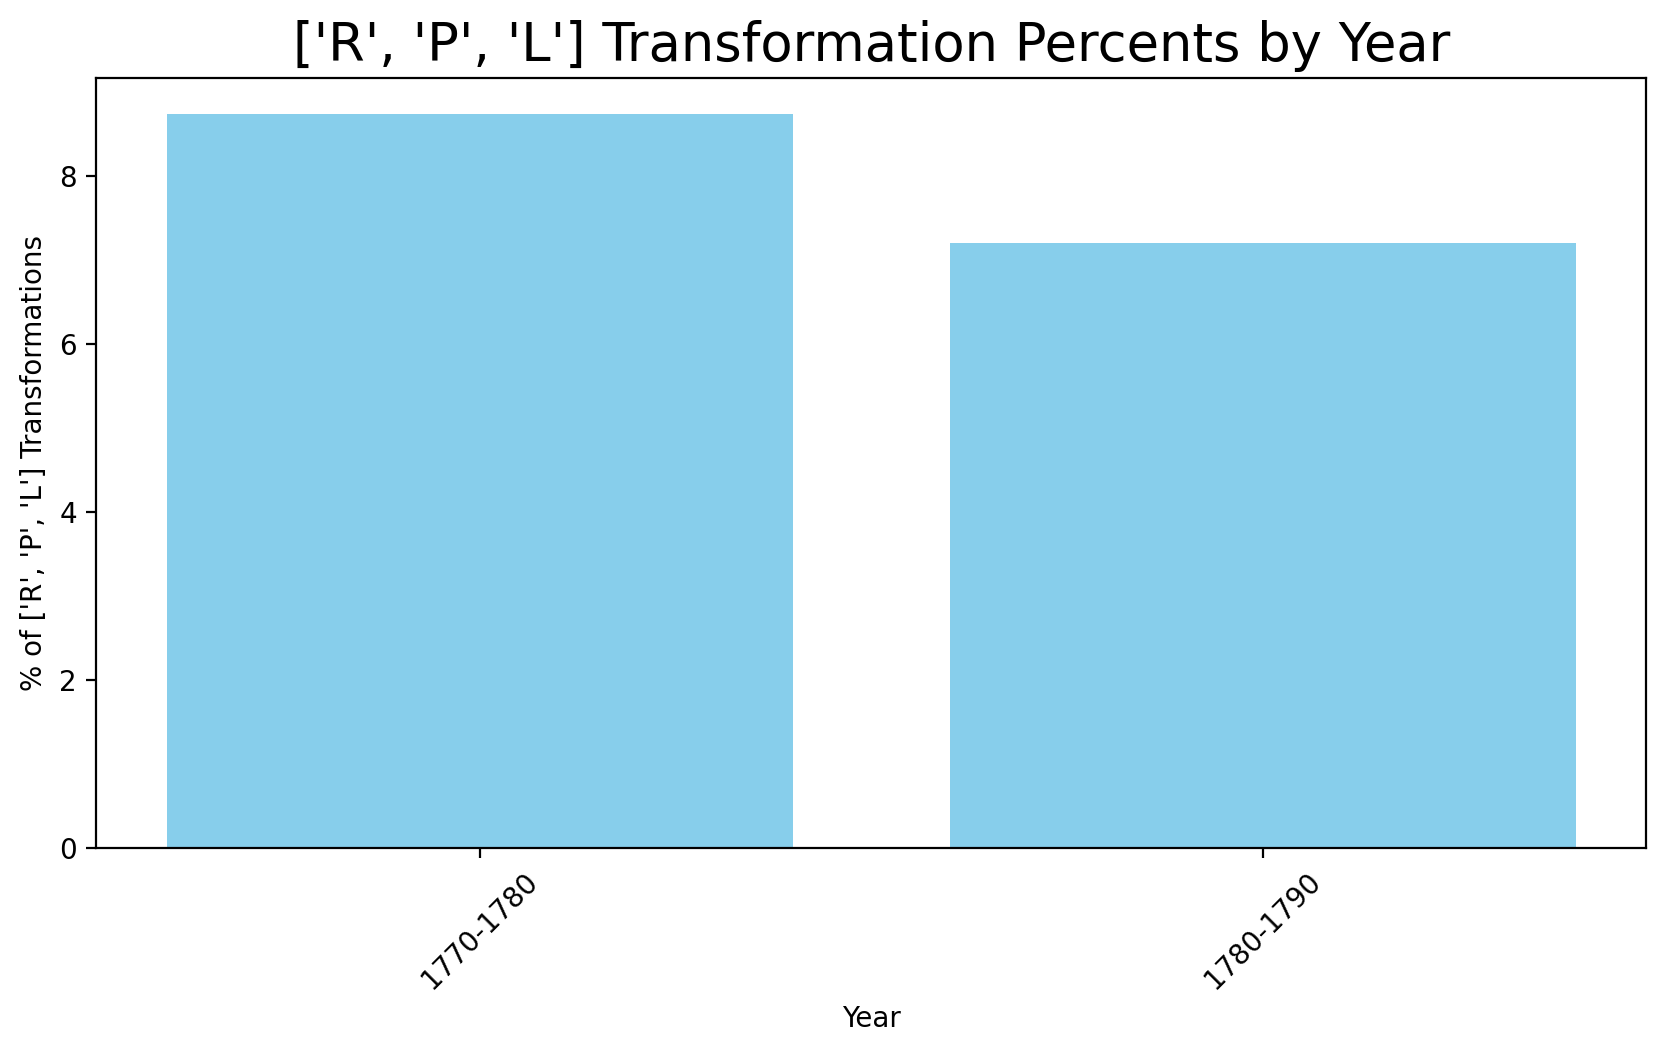

In [101]:
fig, ax, RPL = t.plot_transformation(mozart_transformations_cut, ['R','P','L'])

/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/Importables/tonnetz_utils.py:551: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(P_results['year_bin'], rotation=45)


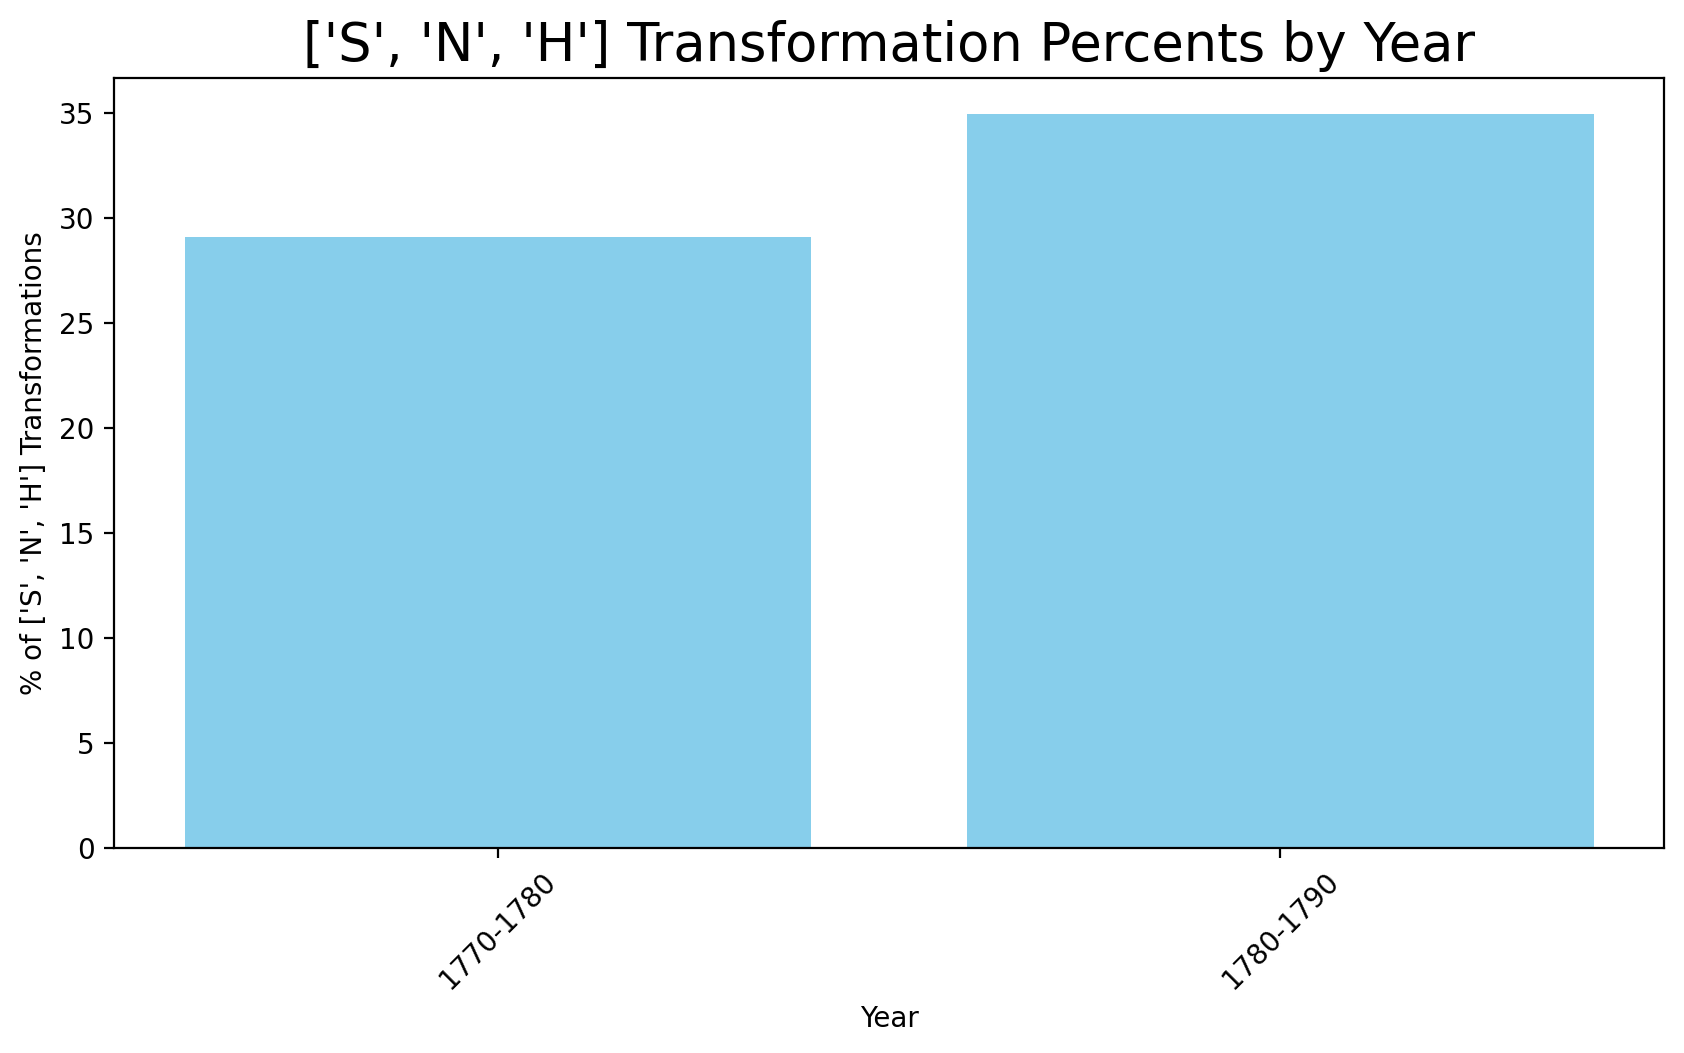

In [103]:
fig, ax, SNH = t.plot_transformation(mozart_transformations_cut, ['S','N','H'])

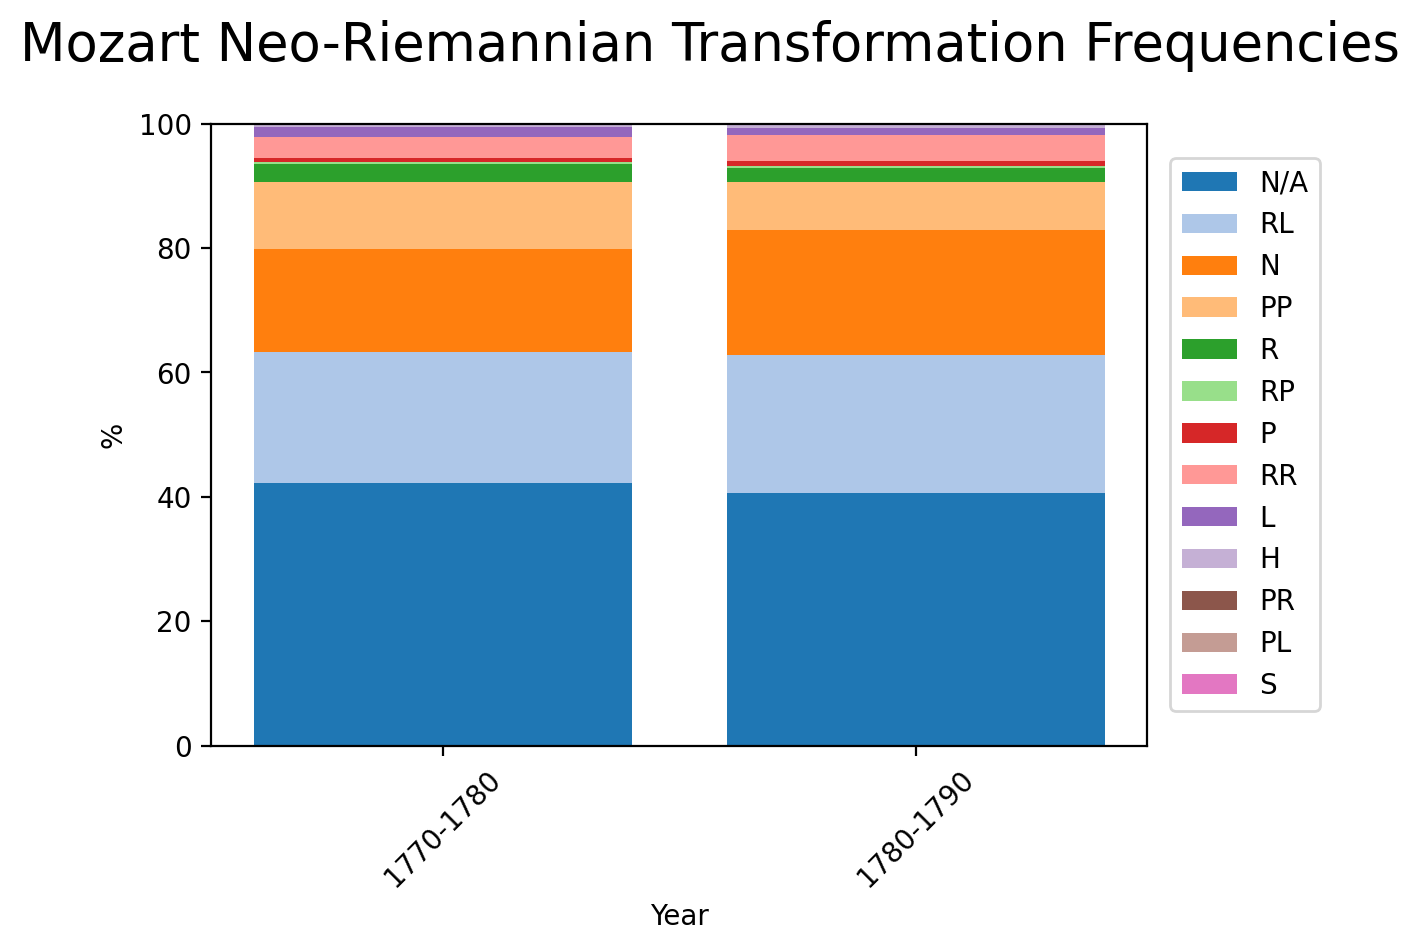

In [108]:
fig, ax = t.bar_plot_transformation(mozart_transformations)
plt.suptitle('Mozart Neo-Riemannian Transformation Frequencies', fontsize=19)
plt.legend(bbox_to_anchor=(1.01,0.5), loc='center left')
plt.tight_layout()
plt.savefig(f"../Results/Mozart_Transformations")
plt.show()

## Beethoven

In [111]:
beethoven_metadata = pd.read_csv("../dcml_corpora/beethoven_piano_sonatas/metadata.tsv", sep='\t')

In [113]:
beethoven = []
for _, row in beethoven_metadata.iterrows():
    piece = row['piece']
    path = '../dcml_corpora/beethoven_piano_sonatas/harmonies/' + piece +'.harmonies.tsv'
    
    try:
        piece_df = pd.read_csv(path, sep='\t')
        piece_df['piece'] = piece
        piece_df['year'] = row['composed_start']
        beethoven.append(piece_df)
    except:
        continue

beethoven = pd.concat(beethoven, ignore_index=True)

In [115]:
beeth_bins = np.arange(1790, 1831, 10) 
beeth_bin_labels = [f"{start}-{start+10}" for start in bins[:-1]]
beethoven['year'] = pd.to_numeric(beethoven['year'], errors='coerce')
beethoven['year_bin'] = pd.cut(beethoven['year'], bins=beeth_bins, labels=beeth_bin_labels, right=False)

In [117]:
beethoven_updated, beethoven_exceptions = update_chord_labels(beethoven)

In [118]:
beethoven_transformations, beethoven_transform_exceptions = transformation(beethoven_updated)

In [119]:
beethoven_transformations_cut = beethoven_transformations[beethoven_transformations['transformation'] != 'N/A'].copy()

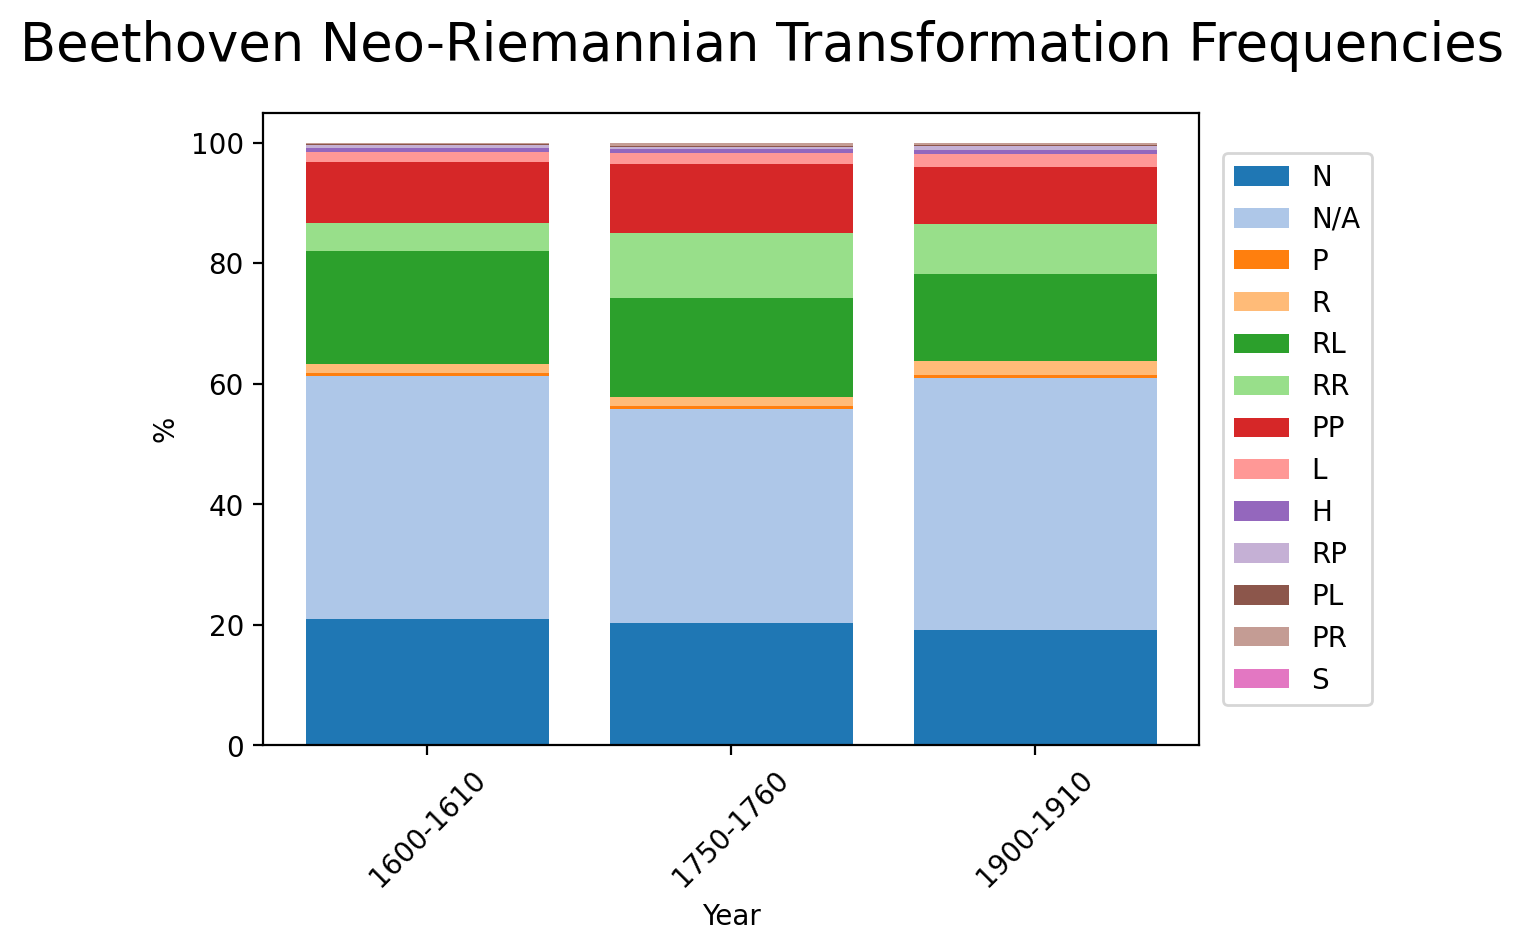

In [121]:
fig, ax = t.bar_plot_transformation(beethoven_transformations)

plt.suptitle('Beethoven Neo-Riemannian Transformation Frequencies', fontsize=19)
plt.legend(bbox_to_anchor=(1.01,0.5), loc='center left')
plt.tight_layout()
#plt.savefig(f"../Results/Beeth_Transformations")
plt.show()

## All

### Transformations

In [129]:
classical_metadata = pd.read_csv("../dcml_corpora/dcml_corpora.metadata.tsv", sep='\t')

In [137]:
# Load harmonies
classical = []
for _, row in classical_metadata.iterrows():
    corpus = row['corpus']
    piece = row['piece']
    path = f'../dcml_corpora/{corpus}/harmonies/{piece}.harmonies.tsv'
    
    try:
        piece_df = pd.read_csv(path, sep='\t')
        piece_df['corpus'] = corpus
        piece_df['piece'] = piece
        piece_df['year'] = row['composed_start']
        classical.append(piece_df)
    except:
        continue

classical = pd.concat(classical, ignore_index=True)

In [139]:
# Bin harmonies by eras
bins = [
    1600,  # Start of Baroque
    1750,  # End of Baroque
    1830,  # End of Classical
    1900,  # End of Romantic
    2000   # End of 20th Century
]
bin_labels = [
    '1600-1750',
    '1750-1830',
    '1830-1900',
    '1900-2000'
]
classical['year'] = pd.to_numeric(classical['year'], errors='coerce')
classical['year_bin'] = pd.cut(classical['year'], bins=bins, labels=bin_labels, right=False)

classical_metadata['year'] = pd.to_numeric(classical_metadata['composed_start'], errors='coerce')
classical_metadata['year_bin'] = pd.cut(classical_metadata['year'], bins=bins, labels=bin_labels, right=False)

In [141]:
classical_updated, classical_exceptions = update_chord_labels(classical)

In [142]:
classical_transformations, classical_transform_exceptions = transformation(classical_updated)

In [143]:
classical_transformations_cut = classical_transformations[classical_transformations['transformation'] != 'N/A'].copy()

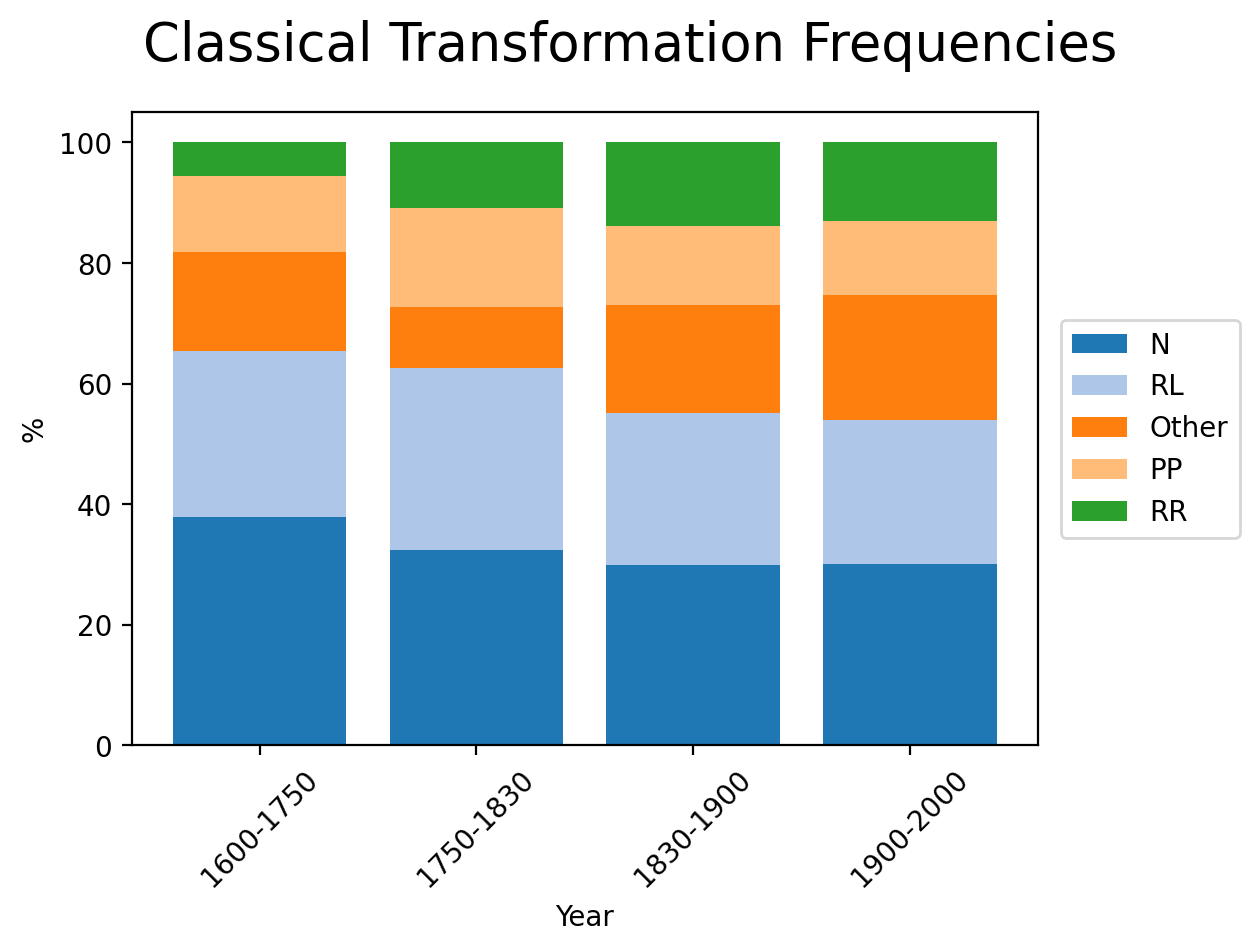

In [147]:
keep = ['N', 'RL', 'PP', 'RR']

classical_plot = classical_transformations_cut.copy()
classical_plot['transformation'] = classical_plot['transformation'].where(
    classical_plot['transformation'].isin(keep),
    'Other'
)

fig, ax = t.bar_plot_transformation(classical_plot)
plt.suptitle('Classical Transformation Frequencies', fontsize=19)
plt.legend(bbox_to_anchor=(1.01,0.5), loc='center left')
plt.tight_layout()
#plt.savefig(f"../Results/Classical_Transformations")
plt.show()

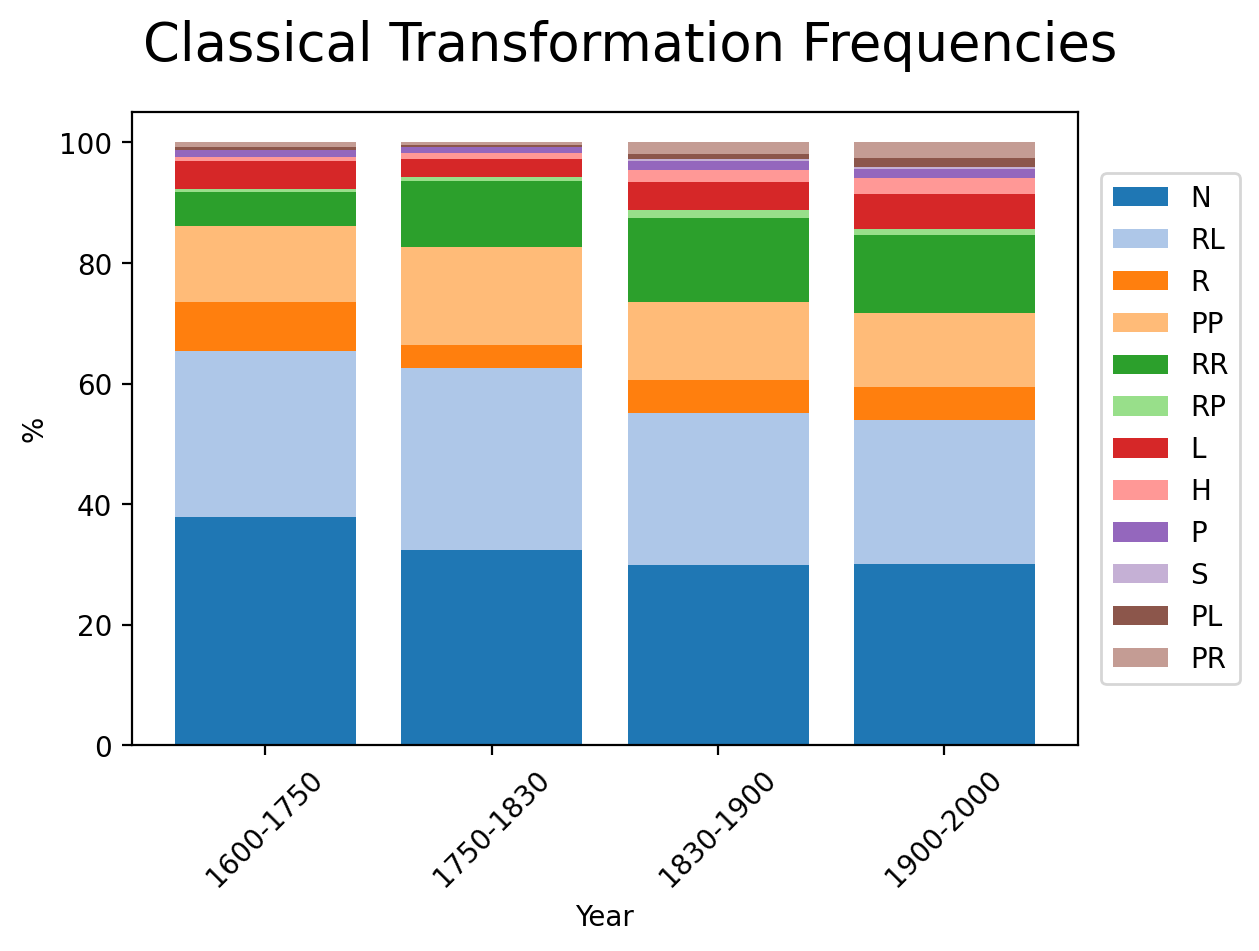

In [149]:
fig, ax = t.bar_plot_transformation(classical_transformations_cut)
plt.suptitle('Classical Transformation Frequencies', fontsize=19)
plt.legend(bbox_to_anchor=(1.01,0.5), loc='center left')
plt.tight_layout()
#plt.savefig(f"../Results/Classical_Transformations")
plt.show()

/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/Importables/tonnetz_utils.py:551: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(P_results['year_bin'], rotation=45)


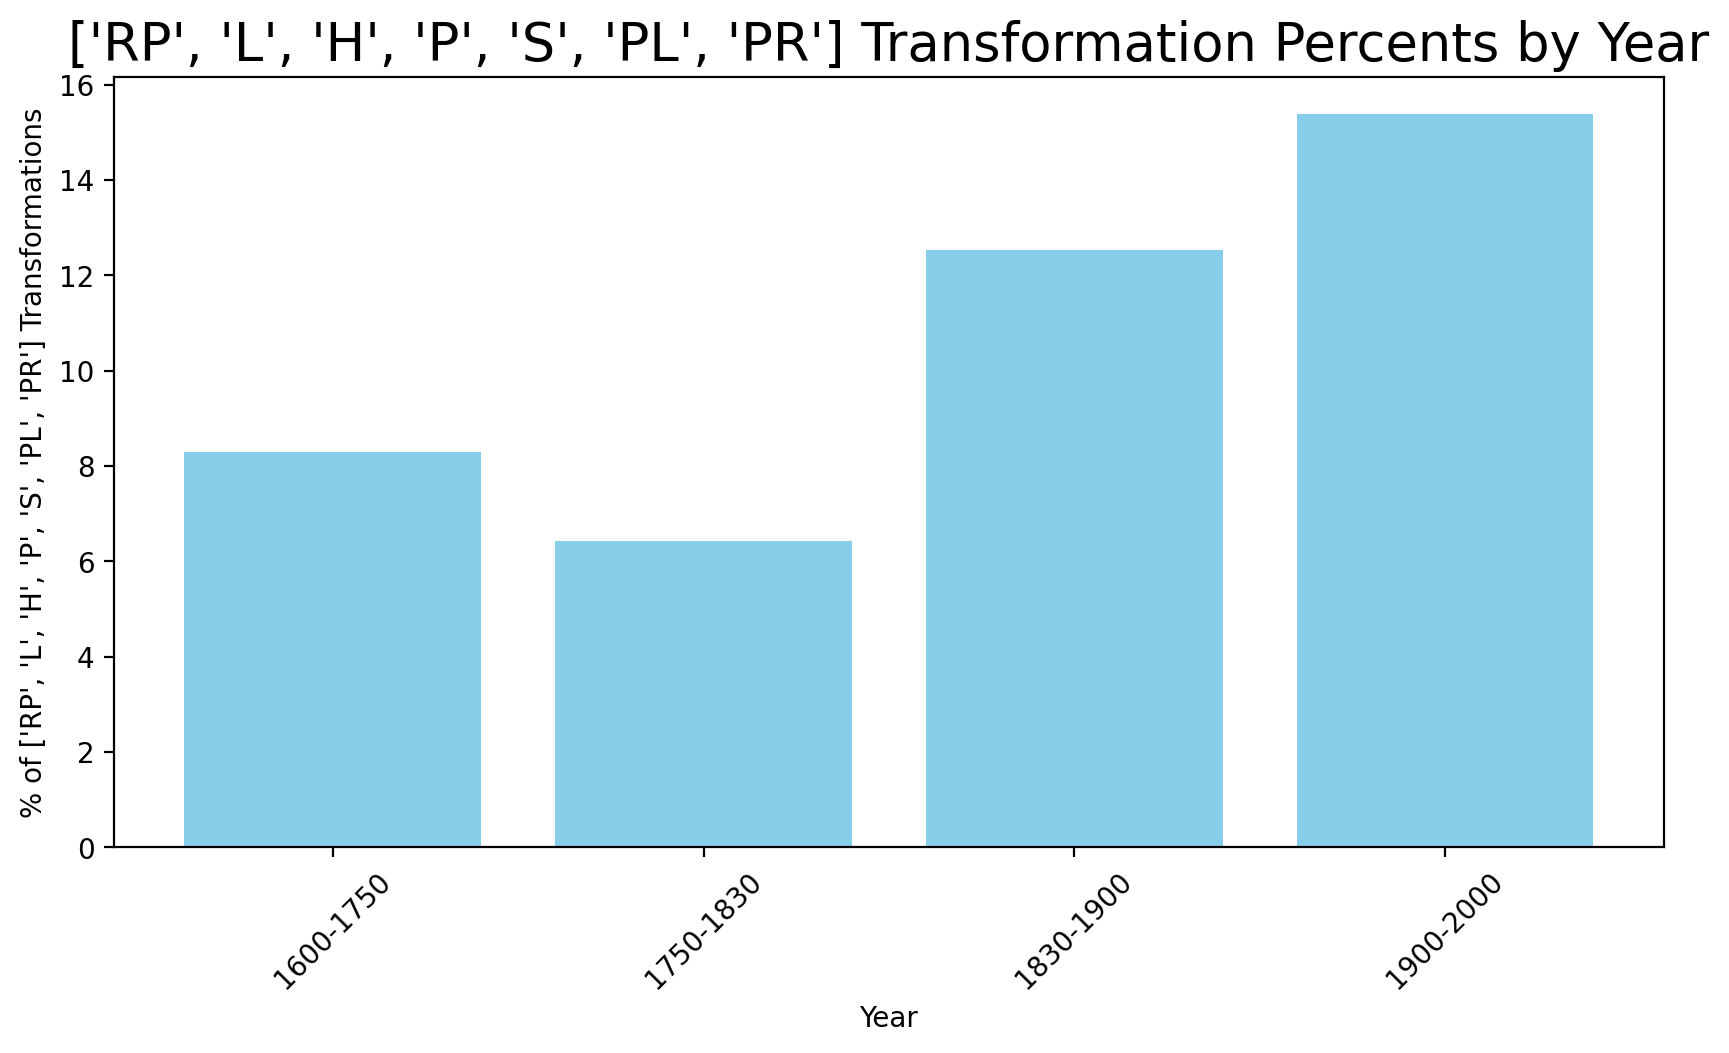

In [152]:
fig, ax, other_trans = t.plot_transformation(classical_transformations_cut, ['RP', 'L', 'H', 'P', 'S', 'PL', 'PR'])

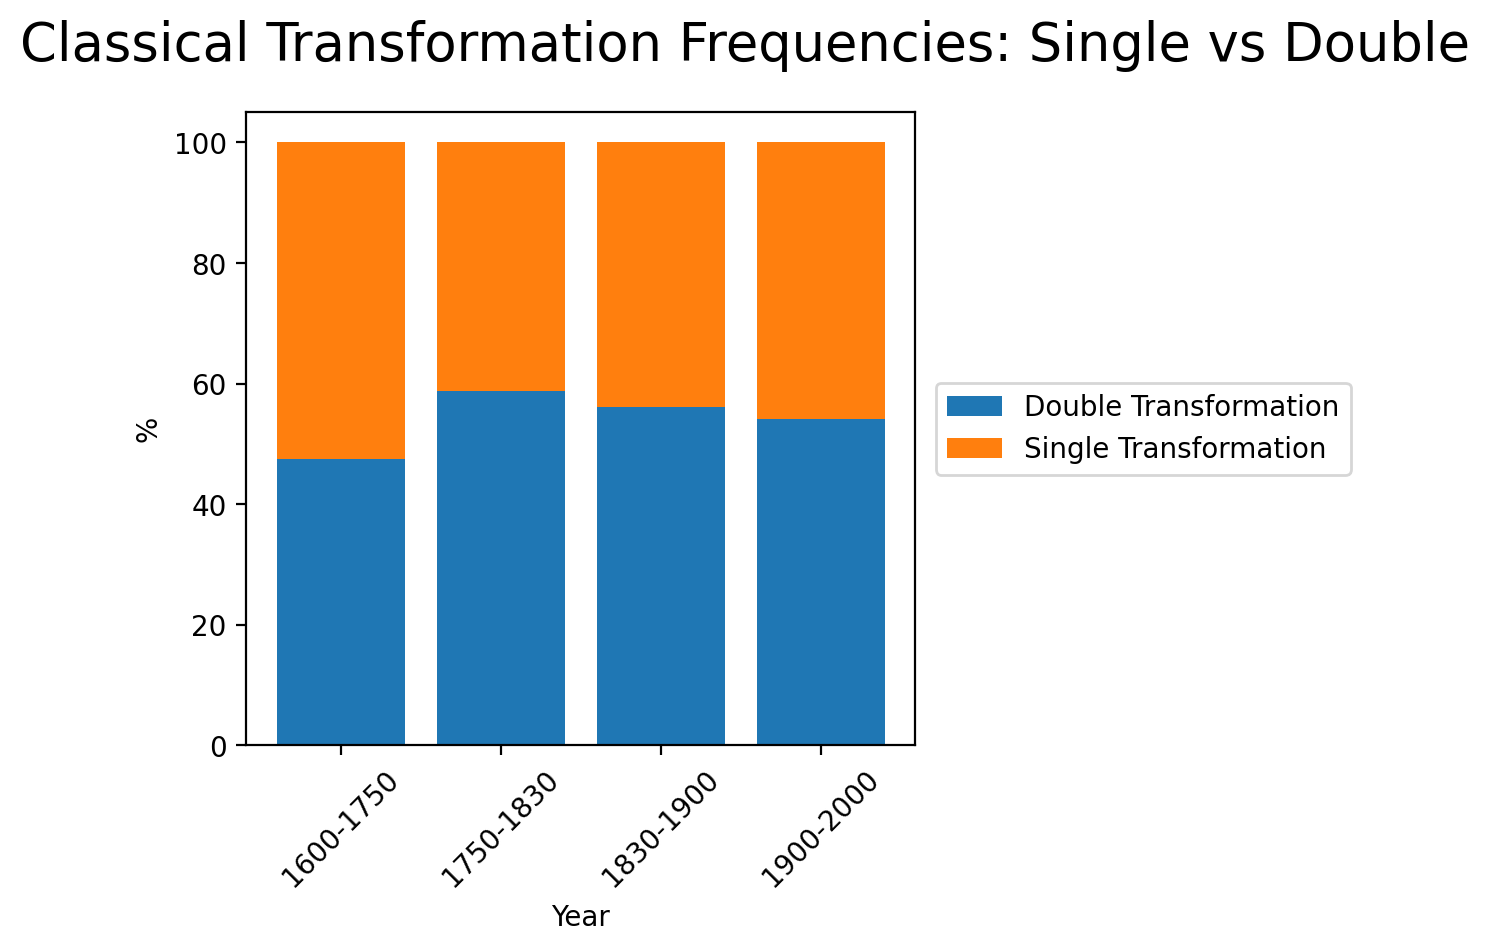

In [162]:
classical_transformations_two = classical_transformations_cut.copy()
classical_transformations_two['transformation'] = classical_transformations_two['transformation'].apply(
    lambda t: 'Double Transformation' if len(t) == 2 else 'Single Transformation'
)


x = bin_labels
num_bins = len(x)

fig, ax = plt.subplots()
current_itn = np.zeros(num_bins)
counts = classical_transformations_two.value_counts(subset=['year_bin']).reset_index(name='count')
counts = counts.sort_values('year_bin')
tot_counts = (
    classical_transformations_two.groupby('year_bin')
    .size()
    .reindex(x, fill_value=0)
)

for trans in classical_transformations_two.value_counts(subset=['transformation']).reset_index(name='count')['transformation']:
    transformation_subset = classical_transformations_two[classical_transformations_two['transformation']== trans]
    transformations_subset_grouped = (
        transformation_subset.groupby('year_bin')
        .size()
        .reindex(x, fill_value=0)
        .reset_index(name='count')
    )
    
    y = transformations_subset_grouped['count'] 
    y = np.array(y) * 100/tot_counts

    ax.bar(x, y, bottom = current_itn, label=trans)

    current_itn = current_itn + y

    ax.set_xticks(np.arange(num_bins))
    ax.set_xlabel('Year')
    ax.set_ylabel('%')
    ax.set_xticklabels(x,rotation=45)

plt.suptitle('Classical Transformation Frequencies: Single vs Double', fontsize=19)
plt.legend(bbox_to_anchor=(1.01,0.5), loc='center left')
plt.tight_layout()
#plt.savefig(f"../Results/Classical_Transformations_1_vs_2")
plt.show()

## Pitch Profile

In [15]:
notes_local = load_notes(classical_metadata, keys='local')
notes_C_local = pa.transpose_to_C(notes_local)

In [21]:
notes_C_local = notes_C_local[notes_C_local['note'].notna()]

notes_C_local = notes_C_local[notes_C_local['recording_year'].notna()].copy()
notes_C_local['year_bin'] = pd.cut(notes_C_local['recording_year'], bins=bins, labels=bin_labels, right=False)


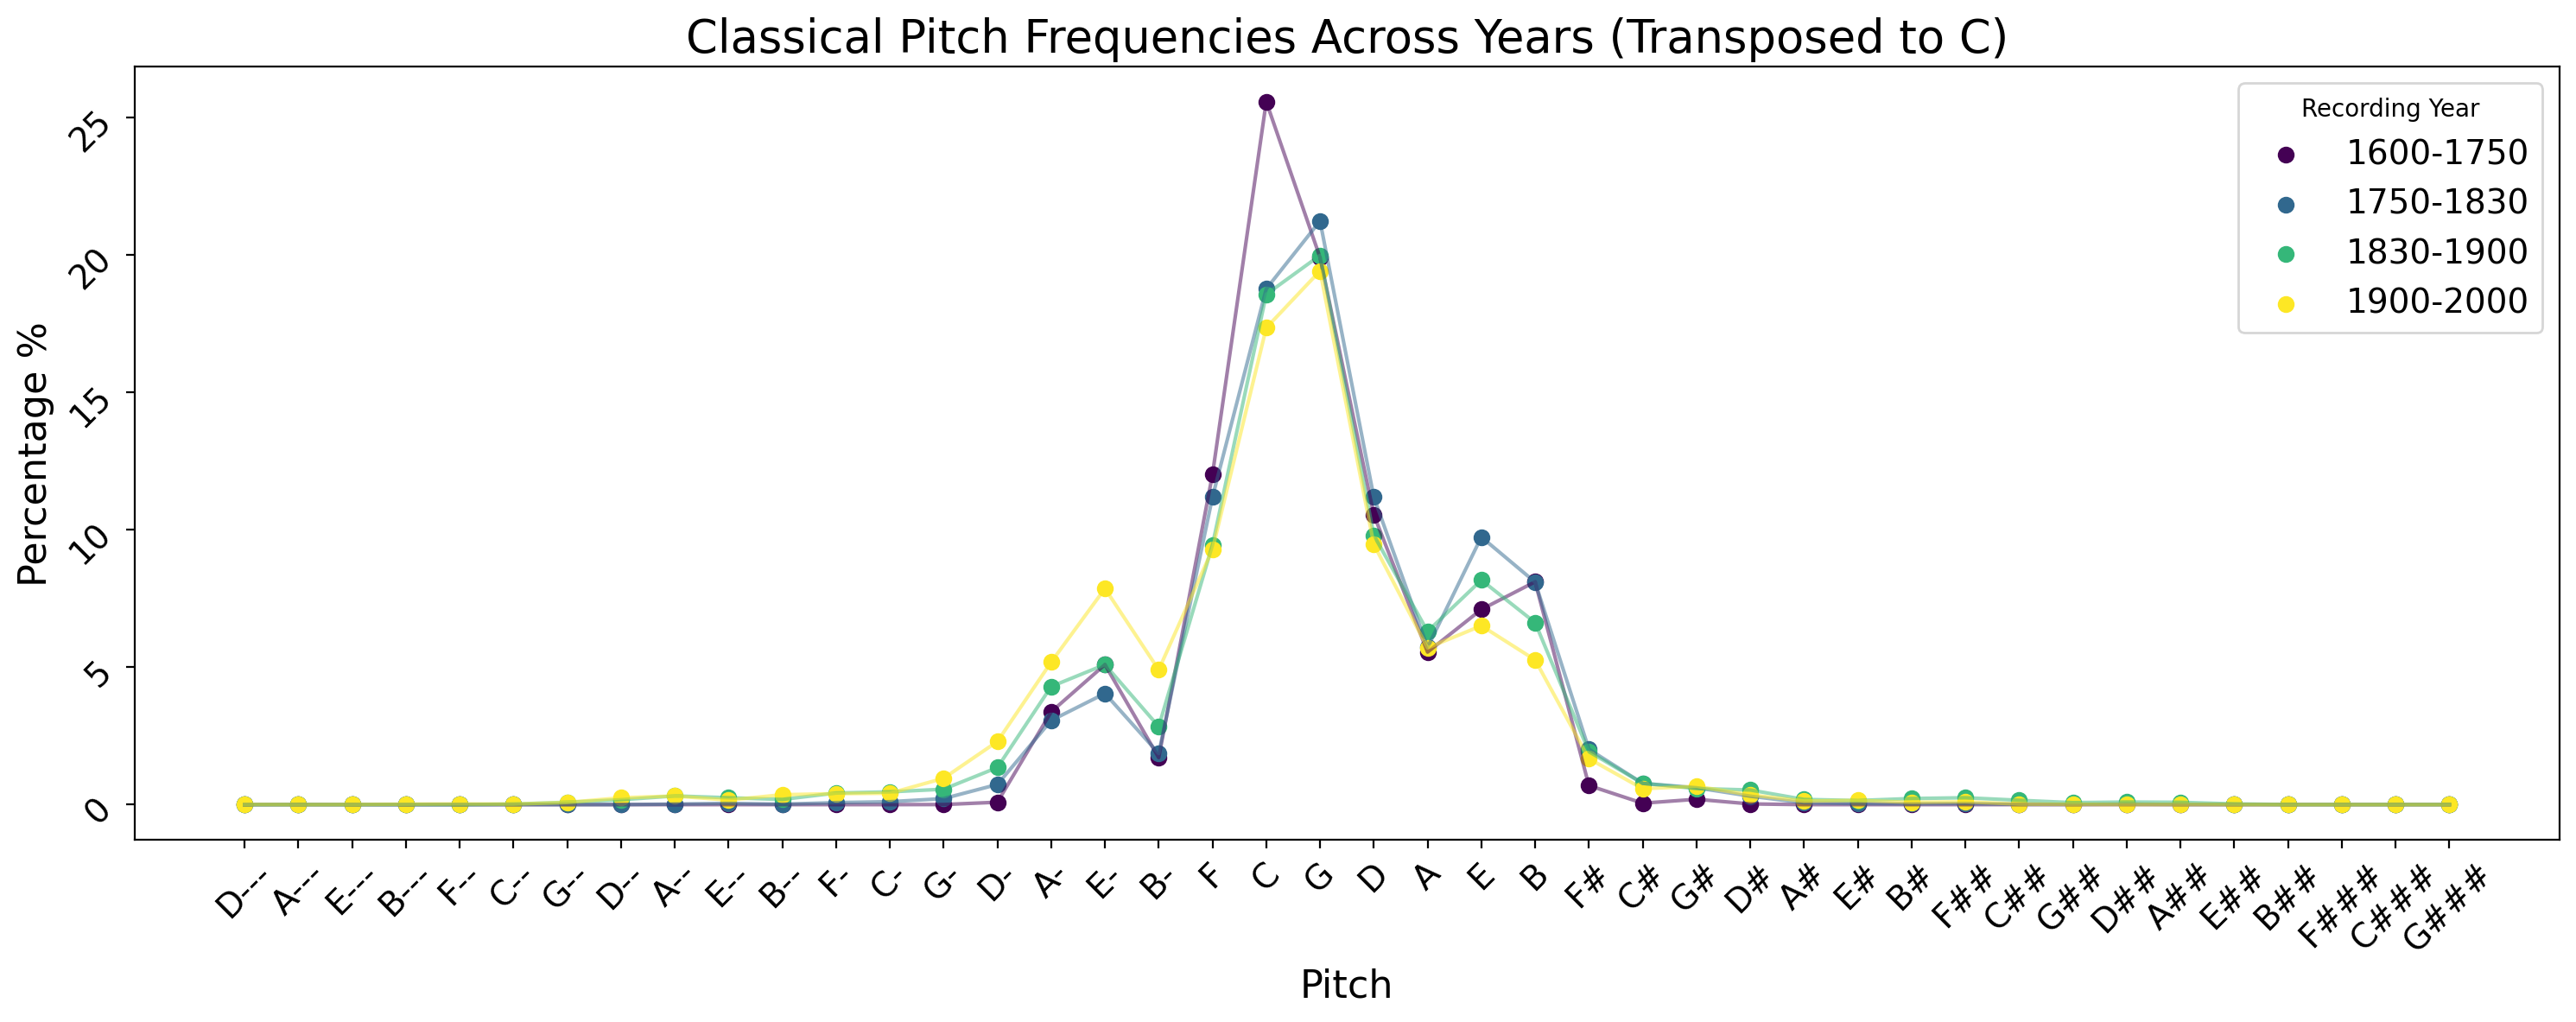

In [62]:
title = 'Classical Pitch Frequencies Across Years (Transposed to C)'
fig, ax = pa.plot_pitch_distribution(notes_C_local, title)
plt.tight_layout()
plt.savefig(f'../Results/ClassicalPitchProfile')
plt.show()  

In [37]:
notes_global = load_notes(classical_metadata, keys='global')

In [ ]:
notes_C_global = pa.transpose_to_C(notes_global)

In [43]:
notes_C_global = notes_C_global[notes_C_global['note'].notna()]

notes_C_global = notes_C_global[notes_C_global['recording_year'].notna()].copy()
notes_C_global['year_bin'] = pd.cut(notes_C_global['recording_year'], bins=bins, labels=bin_labels, right=False)


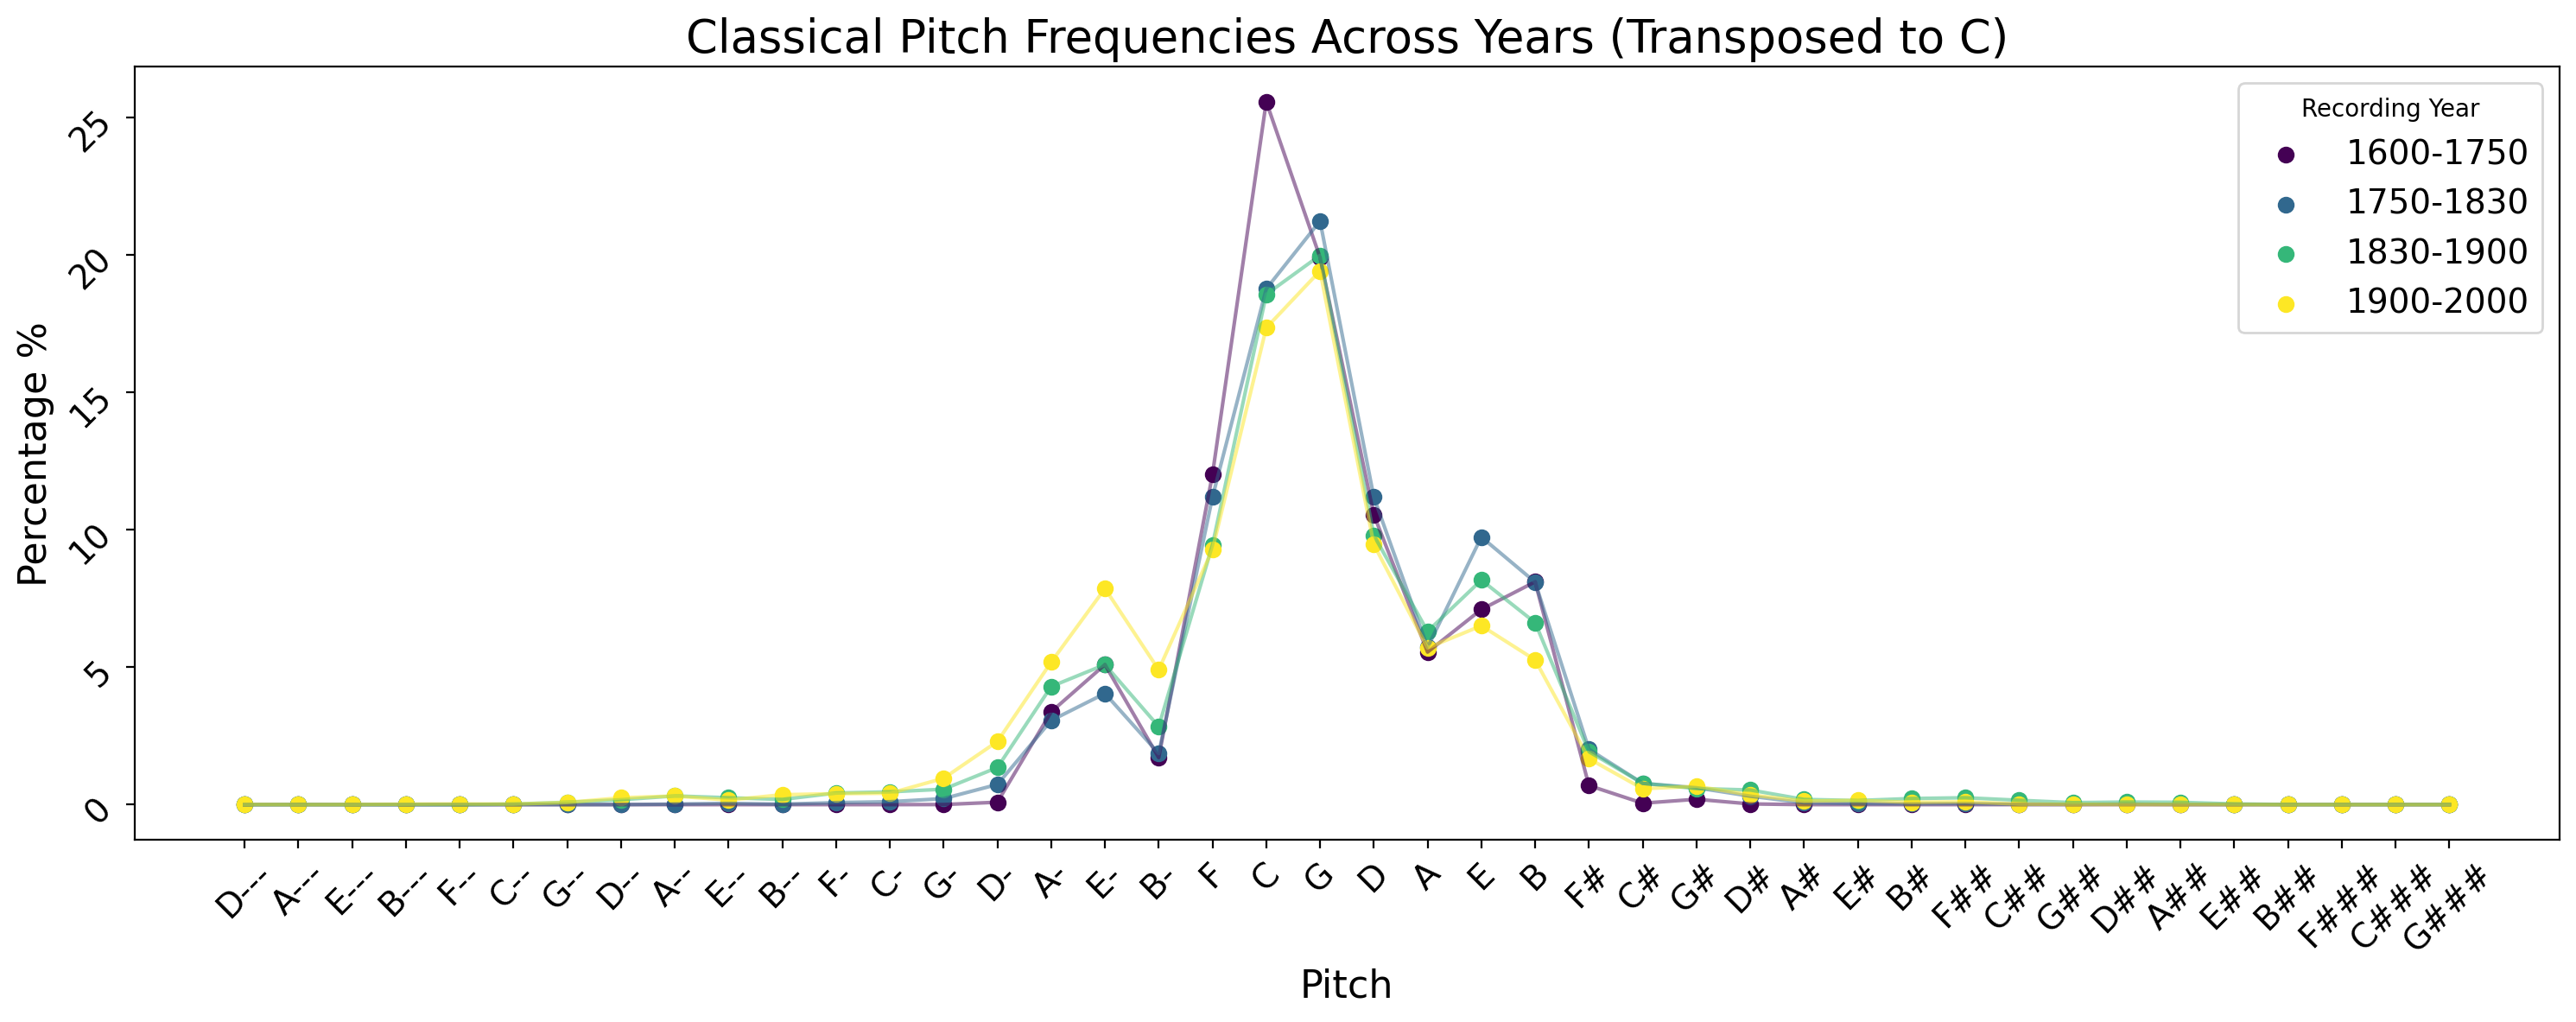

In [60]:
title = 'Classical Pitch Frequencies Across Years (Transposed to C)'
fig, ax = pa.plot_pitch_distribution(notes_C_local, title)
plt.tight_layout()
#plt.savefig(f'../Results/ClassicalPitchProfile')
plt.show() 